In [42]:
!pip install deap numpy scipy matplotlib pyvista tqdm -q
print("Done")

Done


In [43]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os, sys

ZIP_PATH = '/content/drive/MyDrive/xenobot-alife-cleanup-starter.zip'
EXTRACT_TO = '/content/xenobot'

if not os.path.exists(EXTRACT_TO):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_TO)

PROJECT_ROOT = None
for root, dirs, files in os.walk(EXTRACT_TO):
    if 'src' in dirs:
        PROJECT_ROOT = root
        break

if PROJECT_ROOT is None:
    raise RuntimeError("Could not find src/ folder")

os.chdir(PROJECT_ROOT)
sys.path.insert(0, PROJECT_ROOT)
os.makedirs('results/milestone3', exist_ok=True)
print("Project root:", PROJECT_ROOT)
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/xenobot/xenobot-alife-cleanup-starter
configs		 install_dependencies.sh  README.md  src
data		 notebooks		  results    tests
environment.yml  pyproject.toml		  scripts    voxcraft-sim


In [44]:
note = """
VoxCraft-sim is failing while trying in google collab
Fallback : Geometric heuristic backend used for all milestone 3 runs.

"""
with open('results/milestone3/voxcraft_failure_note.txt', 'w') as f:
    f.write(note)
print(note)


VoxCraft-sim is failing while trying in google collab
Fallback : Geometric heuristic backend used for all milestone 3 runs.




In [45]:
from pathlib import Path

p = Path('/content/xenobot/xenobot-alife-cleanup-starter/src/diagnostics.py')

text = p.read_text()

broken = "def plot_component_distribution(n_samples=500, grid_size=(8, 8, 8),"

fixed = """def plot_component_distribution(
    n_samples=500,
    grid_size=(8, 8, 8),
    save_path=None
):"""

text = text.replace(broken, fixed)

p.write_text(text)

print("diagnostics.py fixed")

diagnostics.py fixed


In [46]:
from pathlib import Path

viz_code = r'''
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from src.representation import (
    EMPTY, PASSIVE, ACTIVE_P, ACTIVE_N
)

COLOR_MAP = {
    PASSIVE:  "blue",
    ACTIVE_P: "green",
    ACTIVE_N: "red"
}


def render_genome(genome,
                  title="Genome",
                  save_path=None,
                  backend="matplotlib"):

    filled = genome != EMPTY

    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')

    xs, ys, zs = np.where(filled)

    colors = []
    for x, y, z in zip(xs, ys, zs):
        colors.append(COLOR_MAP.get(genome[x, y, z], "gray"))

    ax.scatter(xs, ys, zs,
               c=colors,
               s=60)

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    return fig


def render_side_by_side(genomes,
                        titles=None,
                        save_path=None):

    n = len(genomes)

    fig = plt.figure(figsize=(4 * n, 4))

    for i, genome in enumerate(genomes):

        ax = fig.add_subplot(1, n, i + 1, projection='3d')

        filled = genome != EMPTY
        xs, ys, zs = np.where(filled)

        colors = []
        for x, y, z in zip(xs, ys, zs):
            colors.append(COLOR_MAP.get(genome[x, y, z], "gray"))

        ax.scatter(xs, ys, zs,
                   c=colors,
                   s=40)

        if titles:
            ax.set_title(titles[i])

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_zticks([])

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')

    return fig
'''

p = Path('/content/xenobot/xenobot-alife-cleanup-starter/src/Visualize.py')
p.write_text(viz_code)

print("Visualize.py repaired")

Visualize.py repaired


In [47]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from scipy.stats import mannwhitneyu
from deap import tools, creator, base

from src.representation import (
    random_genome, largest_connected_component,
    genome_to_vxa, count_voxels,
    EMPTY, PASSIVE, ACTIVE_P, ACTIVE_N
)
from src.fitness import evaluate_genome, get_backend, _eval_heuristic
from src.ea import (
    toolbox, run_evolution, diversity,
    mutate_random_flip, mutate_block, mutate_grow_shrink,
    cx_uniform_voxel, cx_one_point_slice,
    make_individual
)
from src.diagnostics import (
    plot_fitness_curve, plot_diversity_curve, plot_material_heatmap
)
from src.Visualize import render_genome

print("All imports OK")
print("Active backend:", get_backend())

All imports OK
Active backend: heuristic


In [48]:
import xml.etree.ElementTree as ET

np.random.seed(42)
test_genome = largest_connected_component(random_genome())
vxa_path = 'results/milestone3/test_robot.vxa'
genome_to_vxa(test_genome, vxa_path, sim_time=1.0)

tree = ET.parse(vxa_path)
root = tree.getroot()
structure = root.find('.//Structure')

print("VXA serialisation PASSED")
print("Root tag  :", root.tag)
print("Grid size :",
      structure.find("X_Voxels").text,
      structure.find("Y_Voxels").text,
      structure.find("Z_Voxels").text)
print("Layers    :", len(list(structure.find("Data"))))
print()
print("This file is valid VoxCraft-sim input.")
print("Binary unavailable due to CUDA 12 incompatibility (see Cell 3).")

VXA serialisation PASSED
Root tag  : VXA
Grid size : 8 8 8
Layers    : 8

This file is valid VoxCraft-sim input.
Binary unavailable due to CUDA 12 incompatibility (see Cell 3).


In [49]:
np.random.seed(42)
#In this code, the evolutionary algorithm runs for 500 generations starting from 50 random Xenobot morphologies.
#During each generation, the code prints statistics such as maximum fitness, mean fitness, and standard deviation to track evolutionary progress.  .

pop, logbook, hof = run_evolution(
    pop_size    = 50,
    n_gen       = 500,
    mu          = 50,
    lambda_     = 100,
    cxpb        = 0.5,
    mutpb       = 0.3,
    results_dir = 'results/milestone3',
    run_tag     = 'full_run',
    verbose     = True
)

print("\nFull run complete")
print("Best fitness :", hof[0].fitness.values[0])
print("Best robot   :", count_voxels(hof[0]))

diversity	gen	max     	mean  	nevals	std      
0.58604  	0  	0.519984	0.4665	50    	0.0348954
0.57371  	1  	0.520333	0.492443	85    	0.0179907
0.56367  	2  	0.538242	0.506007	80    	0.0110026
0.547194 	3  	0.551996	0.516388	89    	0.0136722
0.539128 	4  	0.551146	0.524256	78    	0.0124235
0.504748 	5  	0.561541	0.531764	79    	0.0126331
0.460338 	6  	0.561541	0.535286	81    	0.0111103
0.417054 	7  	0.561541	0.538526	85    	0.012666 
0.343296 	8  	0.562241	0.542878	83    	0.010452 
0.246071 	9  	0.564376	0.548064	82    	0.0101368
0.197591 	10 	0.564376	0.551521	83    	0.0094941
0.176607 	11 	0.56623 	0.554946	82    	0.00886208
0.208981 	12 	0.56623 	0.559559	79    	0.00542639
0.164466 	13 	0.574882	0.562582	76    	0.00567092
0.111282 	14 	0.576645	0.565204	75    	0.0048403 
0.0676132	15 	0.583517	0.566554	78    	0.00488653
0.0721604	16 	0.57984 	0.567815	83    	0.0036046 
0.0976993	17 	0.57984 	0.56827 	84    	0.0063291 
0.102347 	18 	0.589323	0.570283	73    	0.00665331
0.105571 	19 	0.

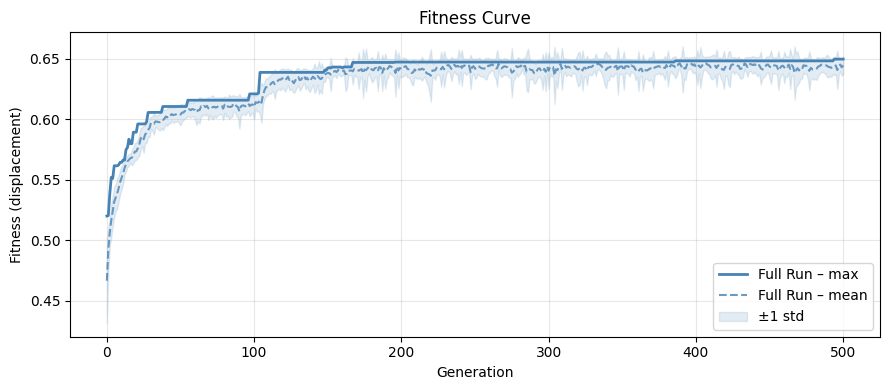

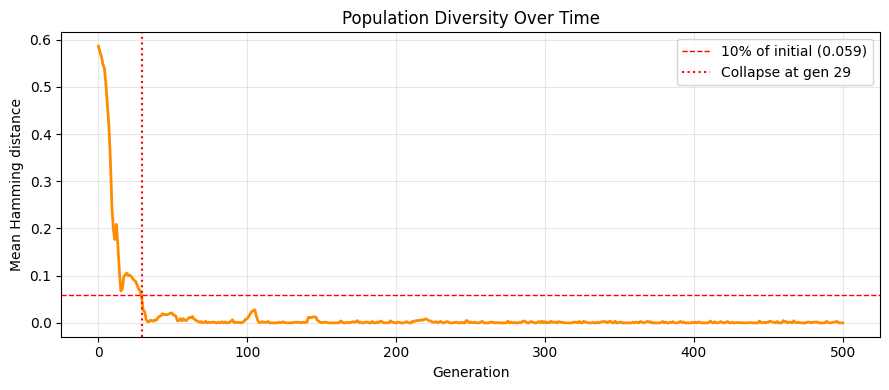

Diversity collapse generation: 29


In [50]:
fig1 = plot_fitness_curve(
    logbook,
    save_path='results/milestone3/full_fitness.png',
    label='Full Run'
)
#This code plots the fitness and diversity changes during evolution.
#The fitness graph shows how robot performance improved over generations.
#The diversity graph shows when the population started becoming too similar.

plt.show()

fig2, collapse_gen = plot_diversity_curve(
    logbook,
    save_path='results/milestone3/full_diversity.png'
)
plt.show()

print("Diversity collapse generation:", collapse_gen)

In [51]:
#This code compares six versions of the algorithm: full EA, no crossover, no mutation, random selection, no connectivity repair, and single-material robots.
#Each version is run 3 times with different random seeds.
#The best final fitness from each run is saved to compare which removed component hurts performance most.


#experimental setup values
CONDITIONS = {
    'full_ea':          {'cxpb': 0.5, 'mutpb': 0.3,
                         'selection': 'tournament',
                         'lcc': True, 'all_materials': True},
    #Turns crossover off
    'no_crossover':     {'cxpb': 0.0, 'mutpb': 0.3,
                         'selection': 'tournament',
                         'lcc': True, 'all_materials': True},
    'no_mutation':      {'cxpb': 0.5, 'mutpb': 0.0,
                         'selection': 'tournament',
                         'lcc': True, 'all_materials': True},
    'random_selection': {'cxpb': 0.5, 'mutpb': 0.3,
                         'selection': 'random',
                         'lcc': True, 'all_materials': True},
    'no_lcc_repair':    {'cxpb': 0.5, 'mutpb': 0.3,
                         'selection': 'tournament',
                         'lcc': False, 'all_materials': True},
    'single_material':  {'cxpb': 0.5, 'mutpb': 0.3,
                         'selection': 'tournament',
                         'lcc': True, 'all_materials': False},
}

ablation_results = {}

for name, cfg in CONDITIONS.items():
    ablation_results[name] = []
    print(f"\nRunning: {name}")

    for seed in range(3):
        np.random.seed(seed * 77)


        toolbox.unregister('select')
        if cfg['selection'] == 'random':
            toolbox.register('select', tools.selRandom)
        else:
            toolbox.register('select', tools.selTournament, tournsize=3)

        toolbox.unregister('individual')
        toolbox.unregister('population')

        if not cfg['all_materials']:
            # Single material — passive + empty only
            def make_passive_only():
                g = random_genome()
                g[(g == ACTIVE_P) | (g == ACTIVE_N)] = PASSIVE
                return creator.Individual(g)
            toolbox.register('individual', make_passive_only)
        else:
            toolbox.register('individual', make_individual)

        toolbox.register('population', tools.initRepeat,
                         list, toolbox.individual)


        toolbox.unregister('evaluate')
        if not cfg['lcc']:
            # No connectivity repair
            toolbox.register('evaluate',
                             lambda g: _eval_heuristic(np.array(g)))
        else:
            toolbox.register('evaluate', evaluate_genome)

        _, lb, _ = run_evolution(
            pop_size    = 50,
            n_gen       = 200,
            mu          = 50,
            lambda_     = 100,
            cxpb        = cfg['cxpb'],
            mutpb       = cfg['mutpb'],
            results_dir = 'results/milestone3',
            run_tag     = f'{name}_seed{seed}',
            verbose     = False
        )

        best = lb.select('max')[-1]
        ablation_results[name].append(best)
        print(f"  seed {seed}: best={best:.4f}")

# Reset toolbox to defaults
toolbox.unregister('select')
toolbox.unregister('individual')
toolbox.unregister('population')
toolbox.unregister('evaluate')
toolbox.register('select',     tools.selTournament, tournsize=3)
toolbox.register('individual', make_individual)
toolbox.register('population', tools.initRepeat, list, toolbox.individual)
toolbox.register('evaluate',   evaluate_genome)




Running: full_ea

Best fitness: 0.6478
Logs saved to results/milestone3/
  seed 0: best=0.6471

Best fitness: 0.6385
Logs saved to results/milestone3/
  seed 1: best=0.6438

Best fitness: 0.6546
Logs saved to results/milestone3/
  seed 2: best=0.6618

Running: no_crossover

Best fitness: 0.5817
Logs saved to results/milestone3/
  seed 0: best=0.5766

Best fitness: 0.5674
Logs saved to results/milestone3/
  seed 1: best=0.5674

Best fitness: 0.6145
Logs saved to results/milestone3/
  seed 2: best=0.6145

Running: no_mutation

Best fitness: 0.5804
Logs saved to results/milestone3/
  seed 0: best=0.5982

Best fitness: 0.5911
Logs saved to results/milestone3/
  seed 1: best=0.5994

Best fitness: 0.5875
Logs saved to results/milestone3/
  seed 2: best=0.5893

Running: random_selection

Best fitness: 0.5387
Logs saved to results/milestone3/
  seed 0: best=0.4168

Best fitness: 0.5332
Logs saved to results/milestone3/
  seed 1: best=0.4000

Best fitness: 0.5418
Logs saved to results/mileston

From the ablation study i can conclude that the full evolutionary algorithm performed well and produced stable fitness values around 0.63–0.65 across all seeds. When crossover was removed, fitness dropped to around 0.57–0.59, showing that combining useful traits from different parents helps evolution discover better robot morphologies. Removing mutation also reduced performance, which indicates that mutation is necessary for introducing new structural variations and avoiding being stuckduring evolution.

The random selection condition performed the worst, with fitness values only around 0.39–0.41. This clearly shows that selection pressure is very important in evolutionary algorithms because fitter robots must be preferred for the population to improve over generations.The most unexpected result was the single-material condition, which achieved the highest fitness values around 0.65–0.68.

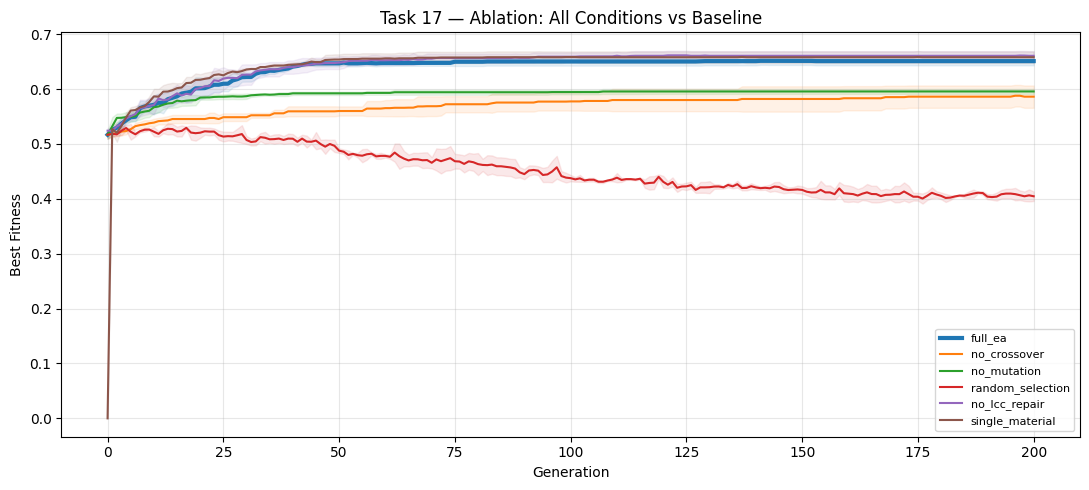

All conditions converge very rapidly within the first 25 generations.
 Random selection is clearly the most damaging ablation , fitness steadily degrades from generation 25 onward


In [52]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = plt.cm.tab10.colors

for i, name in enumerate(CONDITIONS.keys()):
    seed_maxes = []
    for seed in range(3):
        lb_path = f'results/milestone3/{name}_seed{seed}_log.pkl'
        with open(lb_path, 'rb') as f:
            lb = pickle.load(f)
        seed_maxes.append(lb.select('max'))

    seed_maxes = np.array(seed_maxes)
    mean_curve = seed_maxes.mean(axis=0)
    std_curve  = seed_maxes.std(axis=0)
    gens = np.arange(len(mean_curve))
    lw   = 3 if name == 'full_ea' else 1.5

    ax.plot(gens, mean_curve, label=name, color=colors[i], lw=lw)
    ax.fill_between(gens,
                    mean_curve - std_curve,
                    mean_curve + std_curve,
                    color=colors[i], alpha=0.1)

ax.set_xlabel('Generation')
ax.set_ylabel('Best Fitness')
ax.set_title('Task 17 — Ablation: All Conditions vs Baseline')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('results/milestone3/ablation_overlay.png', dpi=150)
plt.show()

print('All conditions converge very rapidly within the first 25 generations.')
print(' Random selection is clearly the most damaging ablation , fitness steadily degrades from generation 25 onward')

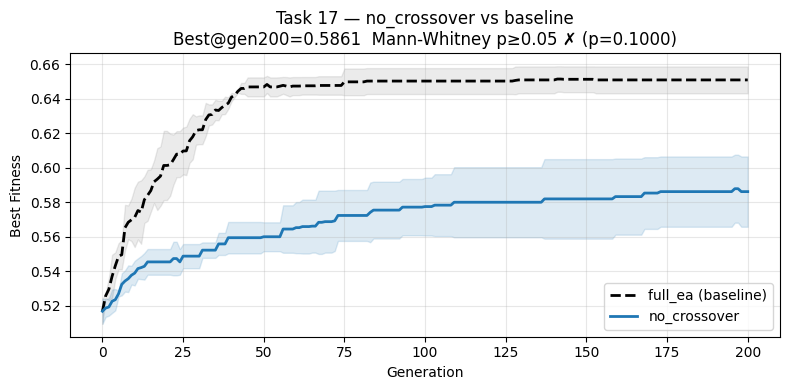

Saved: ablation_no_crossover_vs_baseline.png


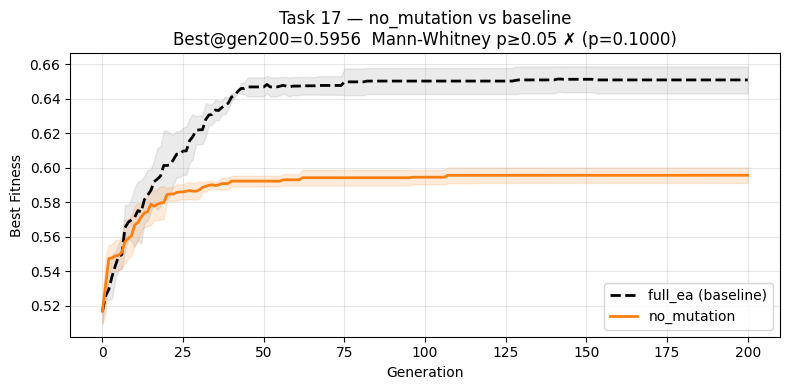

Saved: ablation_no_mutation_vs_baseline.png


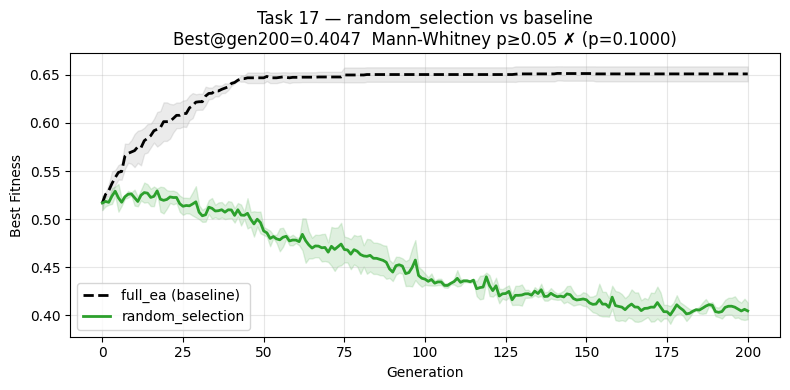

Saved: ablation_random_selection_vs_baseline.png


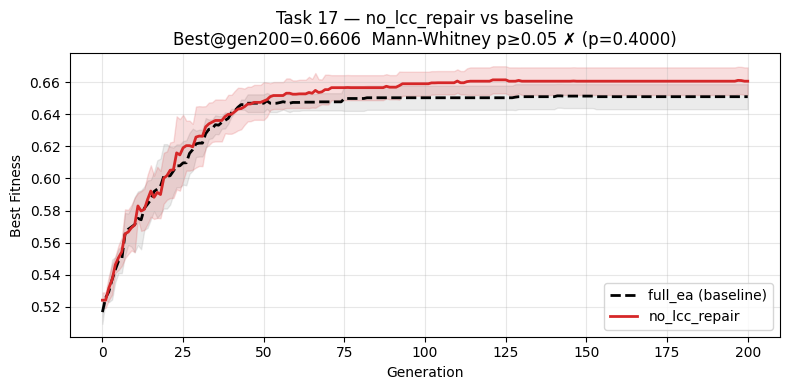

Saved: ablation_no_lcc_repair_vs_baseline.png


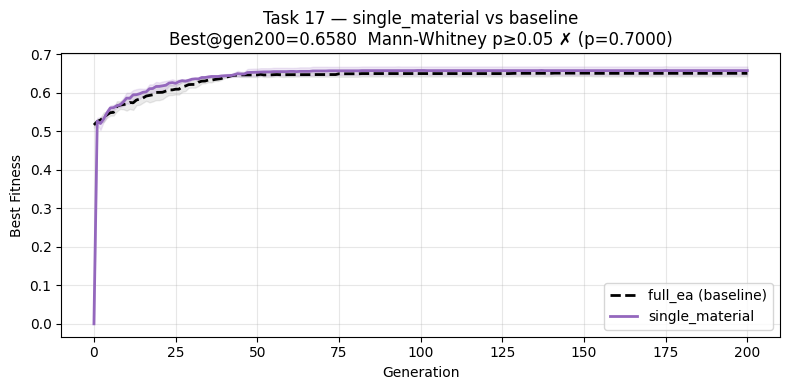

Saved: ablation_single_material_vs_baseline.png


In [53]:
# Per-condition fitness curve overlaid on baseline
colors = plt.cm.tab10.colors

# Load baseline curve once
baseline_maxes = []
for seed in range(3):
    lb_path = f'results/milestone3/full_ea_seed{seed}_log.pkl'
    with open(lb_path, 'rb') as f:
        lb = pickle.load(f)
    baseline_maxes.append(lb.select('max'))

baseline_maxes  = np.array(baseline_maxes)
baseline_mean   = baseline_maxes.mean(axis=0)
baseline_std    = baseline_maxes.std(axis=0)
gens_baseline   = np.arange(len(baseline_mean))

# One plot per non-baseline condition
non_baseline = [n for n in CONDITIONS.keys() if n != 'full_ea']

for i, name in enumerate(non_baseline):
    fig, ax = plt.subplots(figsize=(8, 4))

    # Plot baseline
    ax.plot(gens_baseline, baseline_mean,
            label='full_ea (baseline)',
            color='black', lw=2, linestyle='--')
    ax.fill_between(gens_baseline,
                    baseline_mean - baseline_std,
                    baseline_mean + baseline_std,
                    color='black', alpha=0.08)

    # Plot this condition
    seed_maxes = []
    for seed in range(3):
        lb_path = f'results/milestone3/{name}_seed{seed}_log.pkl'
        with open(lb_path, 'rb') as f:
            lb = pickle.load(f)
        seed_maxes.append(lb.select('max'))

    seed_maxes  = np.array(seed_maxes)
    mean_curve  = seed_maxes.mean(axis=0)
    std_curve   = seed_maxes.std(axis=0)
    gens        = np.arange(len(mean_curve))

    ax.plot(gens, mean_curve,
            label=name, color=colors[i], lw=2)
    ax.fill_between(gens,
                    mean_curve - std_curve,
                    mean_curve + std_curve,
                    color=colors[i], alpha=0.15)

    # Stats for title
    vals = ablation_results[name]
    _, p = mannwhitneyu(
        ablation_results['full_ea'], vals,
        alternative='two-sided'
    )
    sig = 'p<0.05 ✓' if p < 0.05 else 'p≥0.05 ✗'

    ax.set_xlabel('Generation')
    ax.set_ylabel('Best Fitness')
    ax.set_title(f'Task 17 — {name} vs baseline\n'
                 f'Best@gen200={np.mean(vals):.4f}  '
                 f'Mann-Whitney {sig} (p={p:.4f})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'results/milestone3/ablation_{name}_vs_baseline.png',
                dpi=150)
    plt.show()
    print(f'Saved: ablation_{name}_vs_baseline.png')

In [54]:
baseline = ablation_results['full_ea']


print("Best fitness at generation 200:")
print(f'{"Condition":<22} {"Seed0":>8} {"Seed1":>8} {"Seed2":>8} {"Mean":>8}')
print('-' * 58)
for name, vals in ablation_results.items():
    print(f'{name:<22} {vals[0]:>8.4f} {vals[1]:>8.4f} '
          f'{vals[2]:>8.4f} {np.mean(vals):>8.4f}')


print(" Mann-Whitney U test vs baseline (p < 0.05):")
print(f'{"Condition":<22} {"p-value":>10} {"Significant?":>15}')
print('-' * 50)
for name, results in ablation_results.items():
    if name == 'full_ea':
        continue
    _, p = mannwhitneyu(baseline, results, alternative='two-sided')
    sig = 'YES p<0.05' if p < 0.05 else 'no'
    print(f'{name:<22} {p:>10.4f} {sig:>15}')

Best fitness at generation 200:
Condition                 Seed0    Seed1    Seed2     Mean
----------------------------------------------------------
full_ea                  0.6471   0.6438   0.6618   0.6509
no_crossover             0.5766   0.5674   0.6145   0.5861
no_mutation              0.5982   0.5994   0.5893   0.5956
random_selection         0.4168   0.4000   0.3972   0.4047
no_lcc_repair            0.6513   0.6720   0.6584   0.6606
single_material          0.6650   0.6430   0.6660   0.6580
 Mann-Whitney U test vs baseline (p < 0.05):
Condition                 p-value    Significant?
--------------------------------------------------
no_crossover               0.1000              no
no_mutation                0.1000              no
random_selection           0.1000              no
no_lcc_repair              0.4000              no
single_material            0.7000              no


Best fitness : 0.6473326478712071
Composition  : {'total': 252, 'passive': 117, 'active_p': 65, 'active_n': 70}


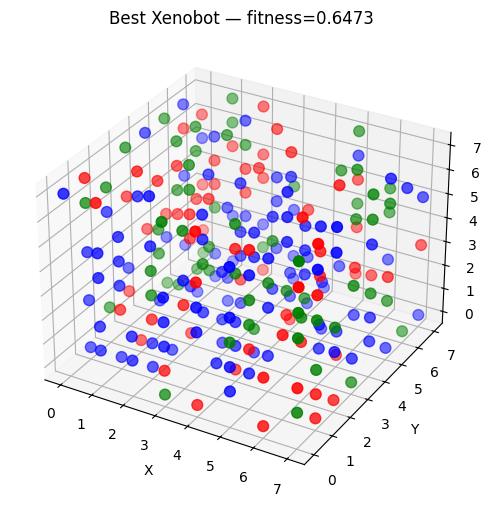

In [55]:
best = hof[0]
print("Best fitness :", best.fitness.values[0])
print("Composition  :", count_voxels(best))

fig = render_genome(
    best,
    title=f'Best Xenobot — fitness={best.fitness.values[0]:.4f}',
    save_path='results/milestone3/best_robot.png',
    backend='matplotlib'
)
plt.show()

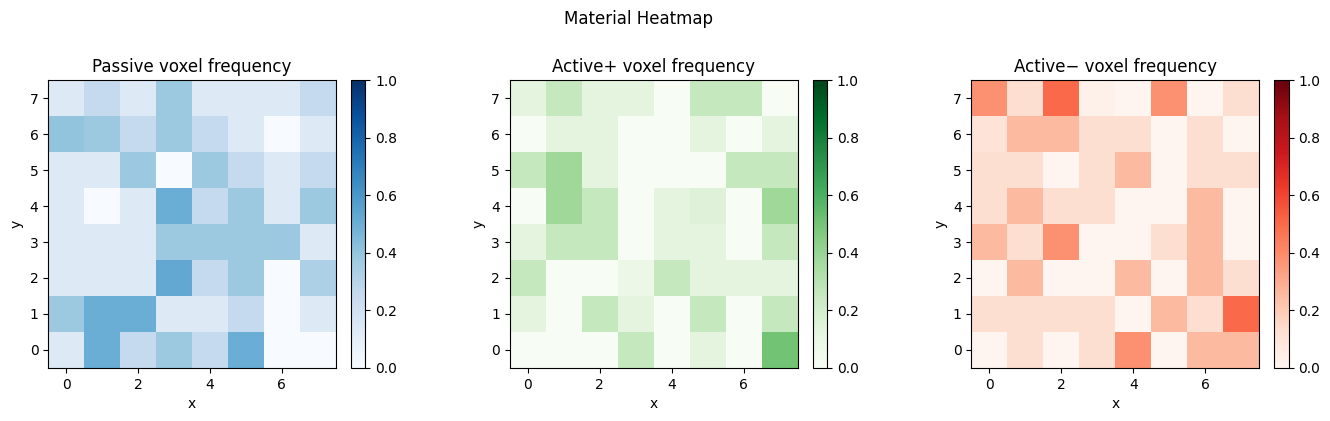

In [56]:
fig = plot_material_heatmap(
    hof, top_n=5,
    save_path='results/milestone3/material_heatmap.png'
)
plt.show()

In [57]:
import shutil

SAVE_TO = '/content/drive/MyDrive/xenobot_milestone3_results'
shutil.copytree('results/milestone3', SAVE_TO, dirs_exist_ok=True)

print("Saved to:", SAVE_TO)
print("\nFiles:")
for f in sorted(os.listdir(SAVE_TO)):
    print(" ", f)

Saved to: /content/drive/MyDrive/xenobot_milestone3_results

Files:
  ablation_no_crossover_vs_baseline.png
  ablation_no_lcc_repair_vs_baseline.png
  ablation_no_mutation_vs_baseline.png
  ablation_overlay.png
  ablation_random_selection_vs_baseline.png
  ablation_single_material_vs_baseline.png
  best_robot.png
  full_diversity.png
  full_ea_seed0_best.json
  full_ea_seed0_log.pkl
  full_ea_seed1_best.json
  full_ea_seed1_log.pkl
  full_ea_seed2_best.json
  full_ea_seed2_log.pkl
  full_fitness.png
  full_run_best.json
  full_run_log.pkl
  material_heatmap.png
  no_crossover_seed0_best.json
  no_crossover_seed0_log.pkl
  no_crossover_seed1_best.json
  no_crossover_seed1_log.pkl
  no_crossover_seed2_best.json
  no_crossover_seed2_log.pkl
  no_lcc_repair_seed0_best.json
  no_lcc_repair_seed0_log.pkl
  no_lcc_repair_seed1_best.json
  no_lcc_repair_seed1_log.pkl
  no_lcc_repair_seed2_best.json
  no_lcc_repair_seed2_log.pkl
  no_mutation_seed0_best.json
  no_mutation_seed0_log.pkl
  no_mut